# Classification Track — Vehicle Loan Default Prediction
23CSE301 ML Capstone — Part A (Review 1) + Part B (Review 2)

**A separate dataset from the regression track:** [Vehicle Loan Default Prediction](https://www.kaggle.com/datasets/mamtadhaker/lt-vehicle-loan-default-prediction) (`data/raw/train.csv`) — borrower and credit-bureau attributes for ~233k vehicle loans, with the goal of predicting whether the loan **defaults** (`loan_default`: 1) or not (0). This is a genuinely different, harder problem from the regression track's price prediction — a realistic binary credit-risk classification task.

**Structure below follows the rubric sections directly:** Section A (Dataset & EDA), Section B (Preprocessing & Feature Engineering), Section D (Classification Track Part A — Review 1). Part B (Section A of the Review 2 rubric) is stubbed at the end.

**Review 1 scope:** Part A — Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree, SVC (5 algorithms).

## Section A — Dataset & EDA

### A1. Dataset Loading & Audit

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")

df = pd.read_csv("../data/raw/train.csv")
print("Shape:", df.shape)
df.info()

Shape: (233154, 41)
<class 'pandas.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 41 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   UniqueID                             233154 non-null  int64  
 1   disbursed_amount                     233154 non-null  int64  
 2   asset_cost                           233154 non-null  int64  
 3   ltv                                  233154 non-null  float64
 4   branch_id                            233154 non-null  int64  
 5   supplier_id                          233154 non-null  int64  
 6   manufacturer_id                      233154 non-null  int64  
 7   Current_pincode_ID                   233154 non-null  int64  
 8   Date.of.Birth                        233154 non-null  str    
 9   Employment.Type                      225493 non-null  str    
 10  DisbursalDate                        233154 non-null  str    
 11  Stat

In [2]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nTarget (loan_default) balance:")
print(df["loan_default"].value_counts(normalize=True).rename("proportion"))

Missing values per column:
Employment.Type    7661
dtype: int64

Target (loan_default) balance:
loan_default
0    0.782929
1    0.217071
Name: proportion, dtype: float64


**Observation:** ~233k loan records, 41 columns, remarkably little missingness (only `Employment.Type`, ~3%). The target is **imbalanced**: ~78% of loans do not default, ~22% do. This matters for Section D — accuracy alone will be a misleading metric here, so weighted Precision/Recall/F1 and ROC-AUC matter more, and `class_weight="balanced"` is worth using in the classifiers that support it.

### A2. EDA Visualisations

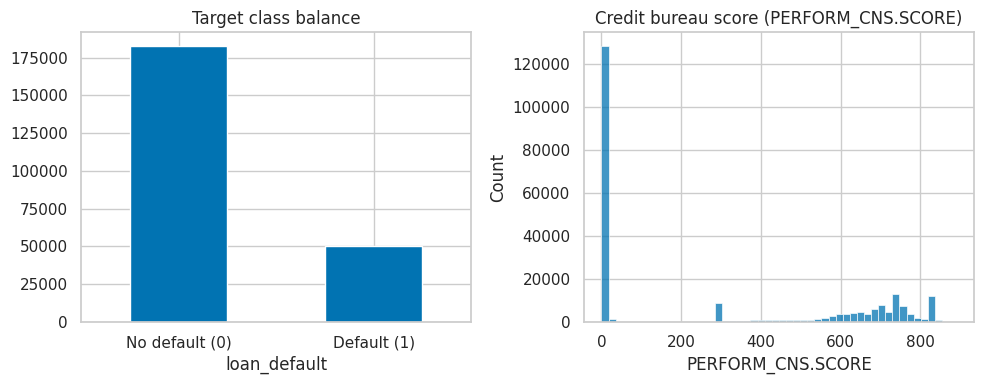

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["loan_default"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_xticklabels(["No default (0)", "Default (1)"], rotation=0)
axes[0].set_title("Target class balance")

sns.histplot(df["PERFORM_CNS.SCORE"], bins=50, ax=axes[1])
axes[1].set_title("Credit bureau score (PERFORM_CNS.SCORE)")
plt.tight_layout()
plt.show()

**Insight (A3):** a large spike of `PERFORM_CNS.SCORE == 0` corresponds to borrowers with **no bureau history** (see the `PERFORM_CNS.SCORE.DESCRIPTION` column) rather than an actual score of zero — this needs to be treated as "no history" rather than a genuinely low score during preprocessing.

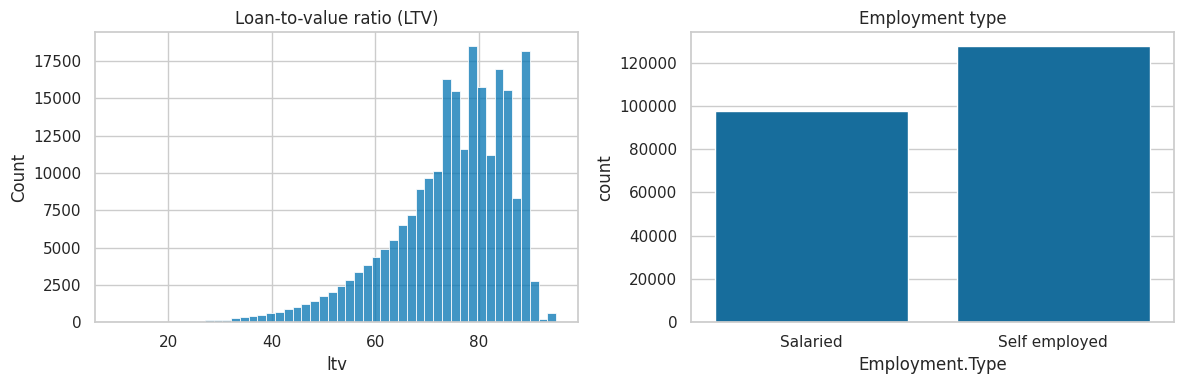

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["ltv"], bins=50, ax=axes[0]).set_title("Loan-to-value ratio (LTV)")
sns.countplot(data=df, x="Employment.Type", ax=axes[1]).set_title("Employment type")
plt.tight_layout()
plt.show()

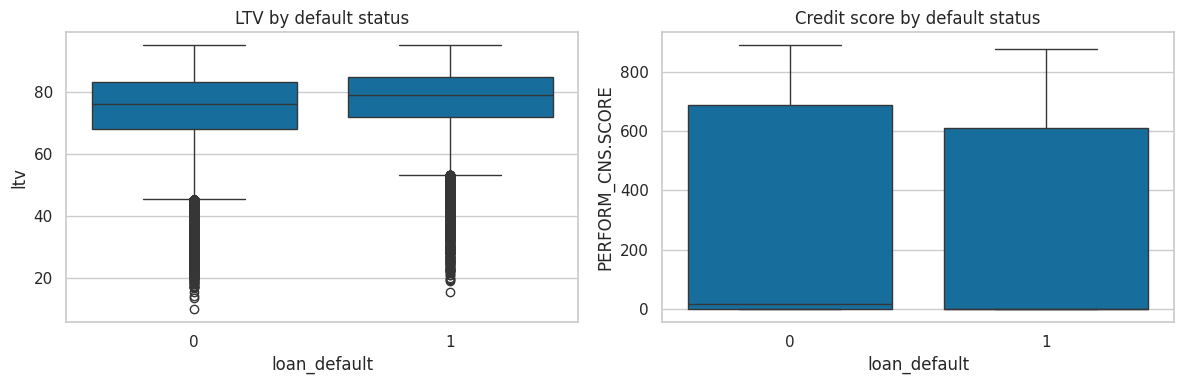

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="loan_default", y="ltv", ax=axes[0]).set_title("LTV by default status")
sns.boxplot(data=df, x="loan_default", y="PERFORM_CNS.SCORE", ax=axes[1]).set_title("Credit score by default status")
plt.tight_layout()
plt.show()

**Insight (A3):** defaulted loans skew towards a *higher* loan-to-value ratio (borrower financed a larger share of the asset's cost, i.e. less 'skin in the game') — a well-known credit-risk signal. The credit-bureau score distributions overlap heavily between the two classes, though, which is a preview of why simple classifiers below (Section D) will only achieve modest separation: this is a genuinely hard dataset, not a toy one.

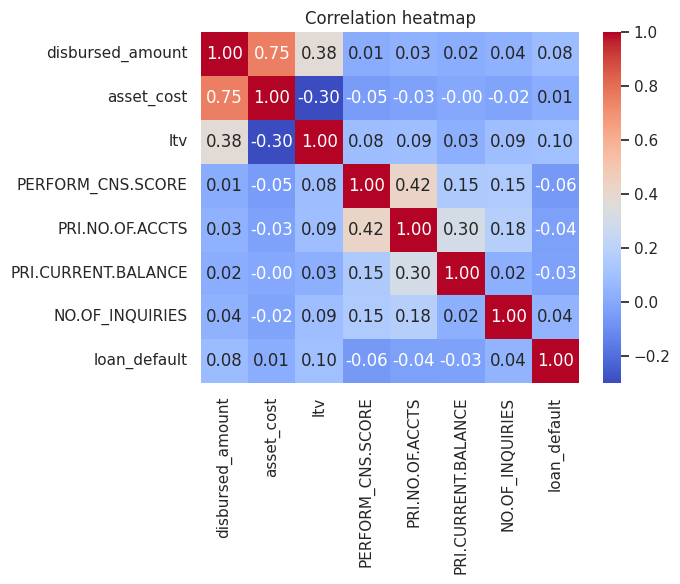

In [6]:
numeric_preview = ["disbursed_amount", "asset_cost", "ltv", "PERFORM_CNS.SCORE", "PRI.NO.OF.ACCTS", "PRI.CURRENT.BALANCE", "NO.OF_INQUIRIES", "loan_default"]
plt.figure(figsize=(7, 6))
sns.heatmap(df[numeric_preview].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

**Insight (A3):** no single numeric feature correlates strongly with `loan_default` in isolation (all |r| well under 0.2) — consistent with the boxplot overlap above. This is a dataset where the signal is diffuse across many weak features rather than concentrated in one or two strong predictors, which is itself a useful, honest finding to report.

## Section B — Preprocessing & Feature Engineering

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df_clean = df.copy()

# --- B3. Feature engineering: parse dates and duration strings into numeric features ---
# Date.of.Birth / DisbursalDate are dd-mm-yy; pandas' default 2-digit-year window can put some
# birth years in the future (e.g. "68" -> 2068) relative to the 2018 disbursal dates, so we
# correct any birth date that lands after its disbursal date back by 100 years.
dob = pd.to_datetime(df_clean["Date.of.Birth"], format="%d-%m-%y")
disb = pd.to_datetime(df_clean["DisbursalDate"], format="%d-%m-%y")
dob_fixed = dob.where(dob <= disb, dob - pd.DateOffset(years=100))
df_clean["age_years"] = (disb - dob_fixed).dt.days / 365.25

def parse_duration(s):
    # "1yrs 11mon" -> total months
    parts = s.replace("yrs", " ").replace("mon", " ").split()
    return int(parts[0]) * 12 + int(parts[1])

df_clean["avg_acct_age_months"] = df_clean["AVERAGE.ACCT.AGE"].apply(parse_duration)
df_clean["credit_history_months"] = df_clean["CREDIT.HISTORY.LENGTH"].apply(parse_duration)

# --- B1. Cleaning ---
# PERFORM_CNS.SCORE == 0 mostly means "no bureau history", not an actual low score;
# PERFORM_CNS.SCORE.DESCRIPTION already carries this distinction, so it's kept as a categorical feature.
# Employment.Type missingness is handled via imputation in the ColumnTransformer below (B2).

numeric_features = ["disbursed_amount", "asset_cost", "ltv", "age_years", "PERFORM_CNS.SCORE",
                     "PRI.NO.OF.ACCTS", "PRI.ACTIVE.ACCTS", "PRI.OVERDUE.ACCTS", "PRI.CURRENT.BALANCE",
                     "PRIMARY.INSTAL.AMT", "NEW.ACCTS.IN.LAST.SIX.MONTHS", "DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS",
                     "avg_acct_age_months", "credit_history_months", "NO.OF_INQUIRIES"]
categorical_features = ["Employment.Type", "PERFORM_CNS.SCORE.DESCRIPTION", "manufacturer_id", "State_ID",
                         "Aadhar_flag", "PAN_flag", "VoterID_flag"]
# Dropped: UniqueID, Date.of.Birth, DisbursalDate (superseded by age_years), AVERAGE.ACCT.AGE /
# CREDIT.HISTORY.LENGTH (superseded by the parsed *_months features), and branch_id / supplier_id /
# Current_pincode_ID / Employee_code_ID (too high-cardinality to one-hot encode meaningfully: 82 / 2,953 /
# 6,698 / 3,270 unique values respectively).

# Subsample for computational feasibility (SVC does not scale well on limited hardware)
df_model = df_clean.sample(n=8000, random_state=RANDOM_STATE).reset_index(drop=True)

X = df_model[numeric_features + categorical_features]
y = df_model["loan_default"]

# --- B2. Stratified split (important given the 78/22 class imbalance), then fit on train only ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
X_train_dense = X_train_proc.toarray() if hasattr(X_train_proc, "toarray") else X_train_proc
X_test_dense = X_test_proc.toarray() if hasattr(X_test_proc, "toarray") else X_test_proc

print("Train shape:", X_train_proc.shape, "Test shape:", X_test_proc.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))

Train shape: (6400, 73) Test shape: (1600, 73)
Train class balance:
 loan_default
0    0.782188
1    0.217812
Name: proportion, dtype: float64


**B3 justification:**
- `age_years`: borrower's age at disbursal is a standard credit-risk feature; raw birth/disbursal date strings are not directly usable by any of the models.
- `avg_acct_age_months` / `credit_history_months`: converting `"1yrs 11mon"`-style strings to a single numeric (months) makes them usable by every model and comparable/orderable, unlike the raw string.

## Section D — Classification Track, Part A (Review 1)

### D1. Implementation — Algorithms 1-5

Fill in each `TODO` below with the corresponding model. Use `X_train_proc` / `X_test_proc` for everything **except** Gaussian Naive Bayes, which needs dense input: `X_train_dense` / `X_test_dense`. For ROC-AUC you'll need `predict_proba`, so pass `probability=True` to SVC. Given the class imbalance noted in Section A, consider `class_weight="balanced"` for Logistic Regression, Decision Tree, and SVC (KNN and Gaussian NB don't support it).

Store every fitted model in `fitted_models[<name>]`, its predictions in `predictions[<name>]`, and its **positive-class** probability in `probabilities[<name>]` (i.e. `model.predict_proba(X_test)[:, 1]`, since this is binary classification) — Section D2 reads from these three dicts, so keep the key names exactly as shown.

In [8]:
fitted_models = {}
predictions = {}
probabilities = {}

**1. Logistic Regression** — Baseline classifier; interpret coefficients/odds. Consider class_weight=\"balanced\".

In [9]:
from sklearn.linear_model import LogisticRegression

# TODO: implement Logistic Regression
# model = ...
# model.fit(X_train_proc, y_train)
# pred = model.predict(X_test_proc)
# proba = model.predict_proba(X_test_proc)[:, 1]  # positive-class ("default") probability
# fitted_models["Logistic Regression"] = model
# predictions["Logistic Regression"] = pred
# probabilities["Logistic Regression"] = proba


**2. KNN** — Tune k; discuss distance metrics.

In [10]:
from sklearn.neighbors import KNeighborsClassifier

# TODO: implement KNN
# model = ...
# model.fit(X_train_proc, y_train)
# pred = model.predict(X_test_proc)
# proba = model.predict_proba(X_test_proc)[:, 1]  # positive-class ("default") probability
# fitted_models["KNN"] = model
# predictions["KNN"] = pred
# probabilities["KNN"] = proba


**3. Gaussian Naive Bayes** — Discuss conditional independence assumption. Needs dense input: X_train_dense / X_test_dense.

In [11]:
from sklearn.naive_bayes import GaussianNB

# TODO: implement Gaussian Naive Bayes
# model = ...
# model.fit(X_train_dense, y_train)
# pred = model.predict(X_test_dense)
# proba = model.predict_proba(X_test_dense)[:, 1]  # positive-class ("default") probability
# fitted_models["Gaussian Naive Bayes"] = model
# predictions["Gaussian Naive Bayes"] = pred
# probabilities["Gaussian Naive Bayes"] = proba


**4. Decision Tree Classifier** — Tune max_depth; visualise the tree. Consider class_weight=\"balanced\".

In [12]:
from sklearn.tree import DecisionTreeClassifier

# TODO: implement Decision Tree Classifier
# model = ...
# model.fit(X_train_proc, y_train)
# pred = model.predict(X_test_proc)
# proba = model.predict_proba(X_test_proc)[:, 1]  # positive-class ("default") probability
# fitted_models["Decision Tree Classifier"] = model
# predictions["Decision Tree Classifier"] = pred
# probabilities["Decision Tree Classifier"] = proba


**5. SVC** — Tune C and kernel; scale features (already done in Section B). Remember probability=True for ROC-AUC and consider class_weight=\"balanced\".

In [13]:
from sklearn.svm import SVC

# TODO: implement SVC
# model = ...
# model.fit(X_train_proc, y_train)
# pred = model.predict(X_test_proc)
# proba = model.predict_proba(X_test_proc)[:, 1]  # positive-class ("default") probability
# fitted_models["SVC"] = model
# predictions["SVC"] = pred
# probabilities["SVC"] = proba


### D2. Evaluation

Once all 5 Part-A models above are filled in, this cell builds the comparison table (Accuracy, Precision, Recall, weighted F1, ROC-AUC) and a confusion matrix for the best model.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

rows = []
for name in fitted_models:
    pred = predictions[name]
    proba = probabilities[name]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted"),
        "Recall": recall_score(y_test, pred, average="weighted"),
        "F1 (weighted)": f1_score(y_test, pred, average="weighted"),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

if rows:
    partA_results = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
    print(partA_results)
else:
    print("TODO: fill in the models in D1 first — fitted_models dict is currently empty.")

TODO: fill in the models in D1 first — fitted_models dict is currently empty.


In [15]:
# TODO: confusion matrix for the best Part-A model (once D1/D2 are complete)
# best_name = partA_results.iloc[0]["Model"]
# cm = confusion_matrix(y_test, predictions[best_name])
# plt.figure(figsize=(5, 4))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No default", "Default"], yticklabels=["No default", "Default"])
# plt.xlabel("Predicted"); plt.ylabel("Actual")
# plt.title(f"Confusion Matrix — {best_name}")
# plt.tight_layout()
# plt.show()

## Section A (Review 2) — Classification Track, Part B

*Completed for Review 2 — Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP Classifier, plus the consolidated 10-algorithm comparison table and final model selection/tuning.*

In [16]:
# TODO (Review 2): train Part B models (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP Classifier)

In [17]:
# TODO (Review 2): consolidated 10-algorithm comparison table (Accuracy, Precision, Recall, F1, ROC-AUC)

In [18]:
# TODO (Review 2): final model selection + hyperparameter tuning + documented improvement